This notebook serves as a demonstration for how the affine observable PMM is used to learn a general machine learning classification/regression problem

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from jax.nn import sigmoid
import jax.numpy as jnp
from jax import grad, lax, jit
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from sklearn.metrics import confusion_matrix
import sys

The problem considered for this demontration is the 2D Exclusive or (XOR) problem with an output of 0 or 1.

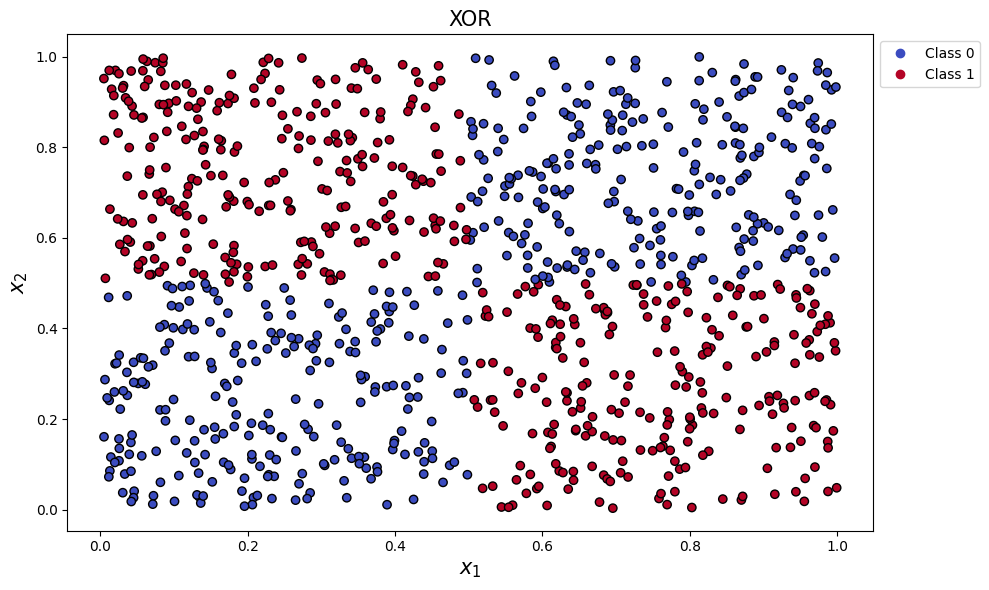

In [2]:
#define XOR function
np.random.seed(42)
def xor(n=1000):
    while (n>0):
        n -=1
        x = np.random.uniform(0,1)
        y = np.random.uniform(0,1)
        if (x<0.5 and y<0.5) or (x>0.5 and y>0.5):
            c = 0
        else:
            c = 1
        yield (x,y,c)

#generate the 'ground truth' dataset
L,C = [],[]
for x,y,c in xor():
    L.append([x,y,c])
L = np.array(L)

#plot
plt.figure(figsize=(10, 6))
sc = plt.scatter(L[:,0], L[:,1], c=L[:,2], cmap='coolwarm',edgecolor='k')
plt.xlabel(r'$x_1$',fontsize=15)
plt.ylabel(r'$x_2$',fontsize=15)
plt.title('XOR',fontsize=15)
handles, labels = sc.legend_elements(prop="colors")
plt.legend(handles, ['Class 0', 'Class 1'], loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [3]:
#split the data into train and test set
X = L[:,:2]
y = L[:,2].reshape(-1,1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Next we construct the affine observable PMM
$$M(x_1,x_2) = A + x_1B+x_2C$$
$$z_k = g_k + \sum_{i, j = 1}^r|v^{(i)\dagger} O_{kij} v^{(j)}|^2 - \frac{1}{2}||O_{kij}||_2^2$$
The PMM is trained with Adam gradient descent method for complex parameters

In [4]:
def M(
    A: jnp.ndarray, B: jnp.ndarray, C: jnp.ndarray, x: jnp.ndarray
) -> jnp.ndarray:
    """
    PMM primary matrix M(x) = A + x[0]*B + x[1]*C

    Parameters
    ----------
    A [2D jax array (n, n)]: Hermitian matrix
    B [2D jax array (n, n)]: Hermitian matrix
    C [2D jax array (n, n)]: Hermitian matrix
    x [1D (2,) or 2D (N, 2) jax array]: single (x1, x2) or N (x1, x2) pairs

    Returns
    -------
    M [2D (n, n) or 3D (N, n, n) jax array]: PMM primary matrix M(x)
        if x is 1D, then returns 2D matrix M(x)
        if x is 2D, then returns 3D matrix where M[i] = M(x[i])

    """
    # force Hermiticity
    A = (A + A.conj().T) / 2
    B = (B + B.conj().T) / 2
    C = (C + C.conj().T) / 2

    if x.ndim == 1:
        return A + x[0] * B + x[1] * C

    else:
        return (
            A
            + jnp.einsum("i,ijk->ijk", x[:, 0], B[np.newaxis, :, :])
            + jnp.einsum("i,ijk->ijk", x[:, 1], C[np.newaxis, :, :])
        )


def predict(
    A: jnp.ndarray,
    B: jnp.ndarray,
    C: jnp.ndarray,
    O: jnp.ndarray,
    g: jnp.ndarray,
    X: jnp.ndarray,
    r: int,
    k: int,
    temperature: float,
) -> jnp.ndarray:
    """
    Perform a forward pass of the model:
        M(x) = A + x[0]*B + x[1]*C
        z_k = g_k + sum_ij^r |<V_i|O_{kij}|V_j>|^2 - ||O_{kij}||_2^2/2
        y_k = sigmoid(z_k)

    Parameters
    ----------
    A [2D jax array (n, n)]: Constant term in the primary matrix M(x)
    B [2D jax array (n, n)]: First linear term in the primary matrix M(x)
    C [2D jax array (n, n)]: Second linear term in the primary matrix M(x)
    O [5D jax array (k, r, r, n, n)]: Array of secondary matrices O_{kij}
        O[:, i, j, :, :] must be equal to O[:, j, i, :, :]
        O[:, :, :, i, j] must be equal to O[:, :, :, j, i].conj()
    g [1D jax array (k,)]: Bias terms
    X [2D jax array (N, 2)]: Input data
    r [int]: Number of eigenvectors of the primary matrix M(x) to use
    k [int]: Number of outputs
    temperature [float]: Temperature parameter, to smooth the output

    Returns
    -------
    y [2D jax array (N, k)]: Predicted labels
    """

    # force O to have the correct form
    # O[:, i, j, :, :] must be equal to O[:, j, i, :, :]
    O = (O + O.transpose(0, 2, 1, 3, 4)) / 2
    # O[:, :, :, i, j] must be equal to O[:, :, :, j, i].conj()
    O = (O + O.transpose(0, 1, 2, 4, 3).conj()) / 2

    # primary matrix M(x)
    Mx = M(A, B, C, X)

    # eigensystem of the primary matrix M(x)
    E, V = jnp.linalg.eigh(Mx)

    # select the r eigenvectors with largest magnitude eigenvalues
    idxs = jnp.argsort(jnp.abs(E), axis=1)
    V = jnp.take_along_axis(V, idxs[:, :, jnp.newaxis], axis=1)[:, :, -r:]

    # <V_i|O_{kij}|V_j>
    VOV = jnp.einsum("nlr,krplm,nmp->nkrp", V.conj(), O, V)

    # ||O_{kij}||_2^2
    norms = jnp.linalg.norm(O, axis=(3, 4), ord=2) ** 2

    z = (
        g.real
        + jnp.einsum("nkrp->nk", jnp.abs(VOV) ** 2)
        - jnp.sum(norms, axis=(1, 2)) / 2
    )

    return sigmoid(z / temperature)


def binary_cross_entropy(
    y_pred: jnp.ndarray, y_true: jnp.ndarray
) -> jnp.ndarray:
    """
    Binary cross-entropy loss function
        L = -y_true * log(y_pred) - (1 - y_true) * log(1 - y_pred)

    Parameters
    ----------
    y_true [1D jax array (N)]: True labels
    y_pred [1D jax array (N)]: Predicted labels

    Returns
    -------
    L [1D jax array (N)]: Loss values
    """

    # careful to avoid log(0)
    log_ypred = jnp.log(jnp.maximum(y_pred, 1e-8))
    log_1_ypred = jnp.log(jnp.maximum(1 - y_pred, 1e-8))

    return -y_true * log_ypred - (1 - y_true) * log_1_ypred



def loss(
    A: jnp.ndarray,
    B: jnp.ndarray,
    C: jnp.ndarray,
    O: jnp.ndarray,
    g: jnp.ndarray,
    X: jnp.ndarray,
    y_true: jnp.ndarray,
    r: int,
    k: int,
    temperature: float,
) -> jnp.ndarray:
    """
    Compute the loss function using binary cross-entropy

    Parameters
    ----------
    A [2D jax array (n, n)]: Constant term in the primary matrix M(x)
    B [2D jax array (n, n)]: First linear term in the primary matrix M(x)
    C [2D jax array (n, n)]: Second linear term in the primary matrix M(x)
    O [5D jax array (k, r, r, n, n)]: Array of secondary matrices O_{kij}
        O[:, i, j, :, :] must be equal to O[:, j, i, :, :]
        O[:, :, :, i, j] must be equal to O[:, :, :, j, i].conj()
    g [1D jax array (k,)]: Bias terms
    X [2D jax array (N, 2)]: Input data
    y_true [1D jax array (N)]: True labels
    r [int]: Number of eigenvectors of the primary matrix M(x) to use
    k [int]: Number of outputs
    temperature [float]: Temperature parameter, to smooth the output

    Returns
    -------
    L [float]: Mean binary cross-entropy loss
    """
    y_pred = predict(A, B, C, O, g, X, r, k, temperature)
    return jnp.mean(binary_cross_entropy(y_pred, y_true))


def complex_adam_update(
    param: jnp.ndarray,
    grad: jnp.ndarray,
    lr: float,
    m: jnp.ndarray,
    v: jnp.ndarray,
    i: int,
    beta1: float = 0.9,
    beta2: float = 0.999,
    eps: float = 1e-8,
    absmaxgrad: float = 1e3,
) -> (jnp.ndarray, jnp.ndarray, jnp.ndarray):
    """
    Adam optimizer update rule, modified for complex valued parameters

    Parameters
    ----------
    param [jax array]: parameter to update
    grad [jax array]: gradient of the loss function wrt param
    lr [float]: learning rate
    m [jax array]: Adam optimizer first moment estimate
    v [jax array]: Adam optimizer second moment estimate
    i [int]: iteration number
    beta1 [float]: Adam optimizer first moment decay rate
    beta2 [float]: Adam optimizer second moment decay rate
    eps [float]: Adam optimizer epsilon parameter
    absmaxgrad [float]: maximum absolute value of the gradient for clipping

    Returns
    -------
    param [jax array]: updated parameter
    m [jax array]: updated first moment estimate
    v [jax array]: updated second moment
    """

    # for complex valued parameters, conjugate the gradient
    # as the gradient descent update rule is
    # x = x - lr * dL/dconj(x)
    # which for real-valued loss functions is equivalent to
    # x = x - lr * conj(dL/dx)

    # we also clip the gradient to avoid exploding gradients
    conj_grad = jnp.clip(grad.real, -absmaxgrad, absmaxgrad) - 1j * jnp.clip(
        grad.imag, -absmaxgrad, absmaxgrad
    )

    # moment estimates
    m = beta1 * m + (1 - beta1) * conj_grad
    v = beta2 * v + (1 - beta2) * jnp.abs(conj_grad) ** 2
    # bias correction
    mhat = m / (1 - beta1 ** (i + 1))
    vhat = v / (1 - beta2 ** (i + 1))

    # update rule
    param = param - lr * mhat / (jnp.sqrt(vhat) + eps)

    return param, m, v


def train(
    A: jnp.ndarray,
    B: jnp.ndarray,
    C: jnp.ndarray,
    O: jnp.ndarray,
    g: jnp.ndarray,
    X_train: jnp.ndarray,
    y_train: jnp.ndarray,
    lr: float = 1e-3,
    n_iter: int = 1000,
    temperature: float = 1.0,
):
    """
    Train the PMM

    Parameters
    ----------
    A [2D jax array (n, n)]: Constant term in the primary matrix M(x)
    B [2D jax array (n, n)]: First linear term in the primary matrix M(x)
    C [2D jax array (n, n)]: Second linear term in the primary matrix M(x)
    O [5D jax array (k, r, r, n, n)]: Array of secondary matrices O_{kij}
        O[:, i, j, :, :] must be equal to O[:, j, i, :, :]
        O[:, :, :, i, j] must be equal to O[:, :, :, j, i].conj()
    g [1D jax array (k,)]: Bias terms
    X_train [2D jax array (N, 2)]: Training input data
    y_train [1D jax array (N)]: Training labels
    lr [float]: learning rate
    n_iter [int]: number of training iterations
    temperature [float]: temperature parameter for the sigmoid function

    Returns
    -------
    A [2D jax array (n, n)]: Trained constant term in the primary matrix M(x)
    B [2D jax array (n, n)]: Trained first linear term in the primary matrix M(x)
    C [2D jax array (n, n)]: Trained second linear term in the primary matrix M(x)
    O [5D jax array (k, r, r, n, n)]: Trained array of secondary matrices O_{kij}
    g [1D jax array (k,)]: Trained bias terms

    """

    # initialize Adam optimizer
    m_A = jnp.zeros_like(A)
    v_A = jnp.zeros_like(A)
    m_B = jnp.zeros_like(B)
    v_B = jnp.zeros_like(B)
    m_C = jnp.zeros_like(C)
    v_C = jnp.zeros_like(C)
    m_O = jnp.zeros_like(O)
    v_O = jnp.zeros_like(O)
    m_g = jnp.zeros_like(g)
    v_g = jnp.zeros_like(g)

    # get r and k
    r = O.shape[1]
    k = g.shape[0]

    # jit version of the loss function with r, k, and temperature fixed
    j_loss = jit(
        lambda A, B, C, O, g, X, y: loss(
            A, B, C, O, g, X, y, r, k, temperature
        )
    )

    # gradient of the loss function wrt A, B, C, O, g
    grad_loss = grad(j_loss, argnums=(0, 1, 2, 3, 4))

    # training loop
    for i in range(n_iter):

        # compute the gradient of the loss function
        grad_A, grad_B, grad_C, grad_O, grad_g = grad_loss(
            A, B, C, O, g, X_train, y_train
        )

        # update
        A, m_A, v_A = complex_adam_update(A, grad_A, lr, m_A, v_A, i)
        B, m_B, v_B = complex_adam_update(B, grad_B, lr, m_B, v_B, i)
        C, m_C, v_C = complex_adam_update(C, grad_C, lr, m_C, v_C, i)
        O, m_O, v_O = complex_adam_update(O, grad_O, lr, m_O, v_O, i)
        g, m_g, v_g = complex_adam_update(g, grad_g, lr, m_g, v_g, i)

        # print loss every 100 iterations
        if i % 100 == 0:
            sys.stdout.write(
                f"\rIteration {i: <7}, Loss: {j_loss(A, B, C, O, g, X_train, y_train):.4E}"
            )
            sys.stdout.flush()

    sys.stdout.write("\n")
    sys.stdout.flush()

    # ensure A, B, C are Hermitian
    A = (A + A.conj().T) / 2
    B = (B + B.conj().T) / 2
    C = (C + C.conj().T) / 2

    # ensure O has the correct form
    O = (O + O.transpose(0, 2, 1, 3, 4)) / 2
    O = (O + O.transpose(0, 1, 2, 4, 3).conj()) / 2

    # discard the imaginary part of g
    g = g.real

    return A, B, C, O, g


With the PMM defined, we can begin training the model my minimizing the binary cross entrop between the true ground truth and the predicted classes

In [5]:
# reshape data
X_train = jnp.array(X_train).reshape(-1,2)
y_train = jnp.array(y_train).reshape(-1,1)

# define parameters
n = 3 #size of PMM
r = 2 #number of eigenvectors to use
k = 1 #number of outputs
lr = 0.001 #learning rate
iterations = 10000

np.random.seed(0)

# Initialize g_k
g = jnp.array(np.random.randn(k)).astype(complex)

# Initialize complex hermitian matrix A
A = jnp.array(np.random.randn(n, n) + 1j * np.random.randn(n, n))
A = (A + A.conj().T)/2

# Initialize complex hermitian matrix B
B = jnp.array(np.random.randn(n, n) + 1j * np.random.randn(n, n))
B = (B + B.conj().T) / 2

# Initialize complex hermitian matrix C
C = jnp.array(np.random.randn(n, n) + 1j * np.random.randn(n, n))
C = (C + C.conj().T) / 2

# Initialize complex hermitian matrices O_kij
O = np.random.randn(k, r, r, n, n) + 1j * np.random.randn(k, r, r, n, n)
O = (O + O.transpose(0, 2, 1, 3, 4)) / 2
O = (O + O.transpose(0, 1, 2, 4, 3).conj()) / 2
O = jnp.array(O)

# scale initial parameters by small prefactor to help training
mag = 0.01
A *= mag
B *= mag
C *= mag
O *= mag
g *= mag


#train model
A,B,C,O,g = train(A, B, C, O, g, X_train, y_train, lr, iterations)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Iteration 9900   , Loss: 1.3969E-04


Finally we use the trained PMM parameters to make a prediction on unseen data

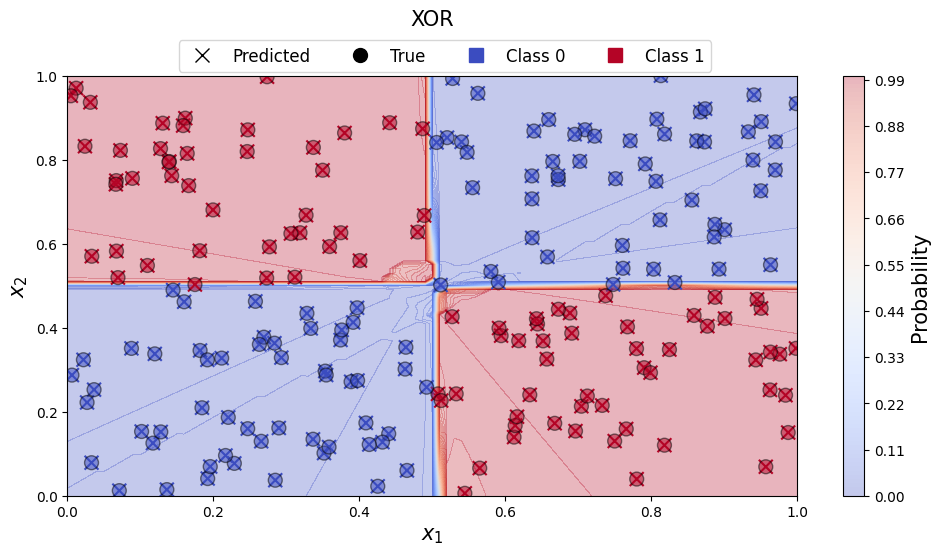

In [6]:
#make prediction
X_test = jnp.array(X_test).reshape(-1,2)
y_test = jnp.array(y_test).reshape(-1,1)
y_pred = predict(A, B, C, O, g, X_test, r, k, temperature=1)
y_pred = (y_pred >= 0.5).astype(int)

# Define the grid range
x_min, x_max = 0, 1.01
y_min, y_max = 0, 1.01
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Flatten the grid to pass through the model
grid = jnp.c_[xx.ravel(), yy.ravel()]

# Predict probabilities on the grid
y_prob_grid = predict(A, B, C, O, g, grid, r, k, temperature=2)

# Reshape the probabilities back to the grid shape
y_prob_grid = y_prob_grid.reshape(xx.shape)

# Plot
plt.figure(figsize=(10, 6))

# Plot probability contours
contour = plt.contourf(xx, yy, y_prob_grid, alpha=0.3, cmap='coolwarm', levels=np.linspace(0, 1, 101))
cbar = plt.colorbar(contour)
cbar.set_label('Probability', fontsize=15)

# Scatter plot for predicted values
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred, cmap='coolwarm', marker='x', s=100, label='Predicted')

# Scatter plot for true values
sc = plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='coolwarm', marker='o', s=100, alpha=0.5, edgecolors='k', label='True')

#labels
plt.xlabel(r'$x_1$', fontsize=15)
plt.ylabel(r'$x_2$', fontsize=15)
plt.title(r'XOR', fontsize=15,y=1.1)

# Create custom legend handles for markers
predicted_handle = mlines.Line2D([], [], color='black', marker='x', linestyle='None', markersize=10, label='Predicted')
true_handle = mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=10, label='True')

# Define colors for class 0 and class 1 based on colormap
cmap = plt.get_cmap('coolwarm')
class_0_color = cmap(0.0)  # Color for class 0
class_1_color = cmap(1.0)  # Color for class 1
class_handles = [
    mlines.Line2D([], [], color=class_0_color, marker='s', linestyle='None', markersize=10, label='Class 0'),
    mlines.Line2D([], [], color=class_1_color, marker='s', linestyle='None', markersize=10, label='Class 1')
]

# Combine legend handles
handles = [predicted_handle, true_handle] + class_handles
labels = [h.get_label() for h in handles]

# Add horizontal legend below the title
plt.figlegend(handles=handles, labels=labels, loc='upper center', bbox_to_anchor=(0.45, 0.93), ncol=len(handles), fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # Adjust layout to make space for legend
plt.show()

In [7]:
# print the confusion matrix
cm =confusion_matrix(y_test, y_pred)

print(cm)

[[108   0]
 [  0  92]]
